In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

reload = mix.reload_module

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

17737
/media/work/docs/codes/QuCF/scripts-py


max. abs. error: 7.708e-01


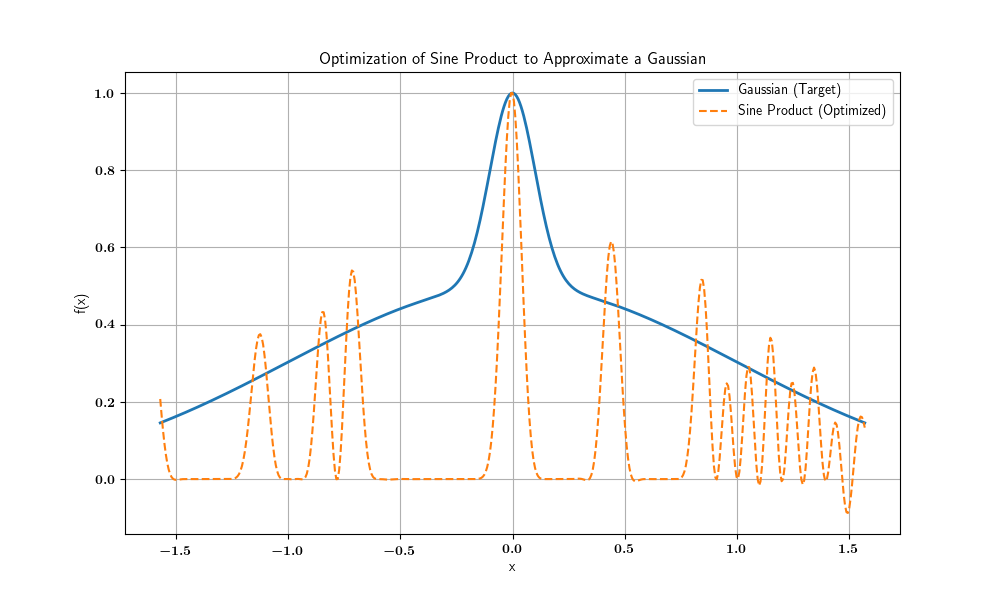

In [27]:


# Define the target Gaussian function
def gaussian(x, mu=0, sigma=1):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) + np.exp(-0.5 * ((x - mu/2.) / (0.1*sigma)) ** 2)


# Define the product of sine functions
def sine_product(Nx, params):
    result = 1.0
    Npars_loc = len(params)
    for i_par in range(0, Npars_loc, 2):
        x_left = - params[i_par]
        dx = 2. * params[i_par+1] / Nx
        x = np.array([x_left + j*dx for j in range(int(Nx))])
        result *= np.sin(x)
    return result


# Define the objective function (mean squared error)
def objective(params, Nx, target):
    approximation = sine_product(Nx, params)
    approximation /= np.max(np.abs(approximation))
    return np.mean((approximation - target) ** 2)

# Parameters
mu, sigma = 0, 1
Nx = 501
xmax_ref = np.pi/2.
dx_ref = xmax_ref * Nx / (Nx-1)
x_ref = np.linspace(-xmax_ref, xmax_ref, Nx)

N_sin = 20


# --- the target function ---
target = gaussian(x_ref, mu, sigma)
target /= np.max(np.abs(target))

# --- Initial parameters ---
Npars = N_sin * 2
initial_params = np.zeros(Npars)
for i_par in range(0, Npars, 2): 
    # initial_params[i_par] = xmax_ref
    # initial_params[i_par+1] = xmax_ref * Nx / (Nx-1)

    initial_params[i_par] = np.random.uniform(-10.*xmax_ref, 10.*xmax_ref, size=1)[0]
    initial_params[i_par+1] = np.random.uniform(-10.*dx_ref, 10.*dx_ref, size=1)[0]


# initial_params = np.random.uniform(0.5, 5, size=5)  # Random initial guesses for 5 sine terms

# Perform the optimization
result = minimize(
    objective, 
    initial_params, 
    args=(Nx, target), 
    method='L-BFGS-B'
)

# Get the optimized parameters
optimized_params = result.x

# Compute the optimized sine product approximation
optimized_approximation = sine_product(Nx, optimized_params)
optimized_approximation /= np.max(np.abs(optimized_approximation))

# --- Maximum error ---
abs_error = np.max(np.abs(target - optimized_approximation))
print("max. abs. error: {:0.3e}".format(abs_error))


# --- Plotting the results ---
plt.figure(figsize=(10, 6))
plt.plot(x_ref, target, label="Gaussian (Target)", linewidth=2)
plt.plot(x_ref, optimized_approximation, label="Sine Product (Optimized)", linestyle="--")
plt.title("Optimization of Sine Product to Approximate a Gaussian")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()

In [2]:
for i_par in range(0, 10, 2): 
    print(i_par)

0
2
4
6
8


In [5]:
x = np.array([-1 + j*0.1 for j in range(20)])
x

array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
        0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9])

In [ ]:
# # Define the target Gaussian function
# def gaussian(x, mu=0, sigma=1):
#     return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# # Define the product of sine functions
# def sine_product(x, params):
#     result = 1.0
#     for k, omega in enumerate(params):
#         result *= np.sin(omega * x)
#     return result

# # Define the objective function (mean squared error)
# def objective(params, x, target):
#     approximation = sine_product(x, params)
#     approximation /= np.max(np.abs(approximation))

#     return np.mean((approximation - target) ** 2)

# # Parameters
# mu, sigma = 0, 1
# x = np.linspace(-2 * np.pi, 2 * np.pi, 500)

# target = gaussian(x, mu, sigma)

# target /= np.max(np.abs(target))

# # Initial guesses for the sine parameters (frequencies)
# initial_params = np.random.uniform(0.5, 5, size=5)  # Random initial guesses for 5 sine terms

# # Perform the optimization
# result = minimize(objective, initial_params, args=(x, target), method='L-BFGS-B')

# # Get the optimized parameters
# optimized_params = result.x

# # Compute the optimized sine product approximation
# optimized_approximation = sine_product(x, optimized_params)

# # Plot the results
# plt.figure(figsize=(10, 6))
# plt.plot(x, target, label="Gaussian (Target)", linewidth=2)
# plt.plot(x, optimized_approximation, label="Sine Product (Optimized)", linestyle="--")
# plt.title("Optimization of Sine Product to Approximate a Gaussian")
# plt.xlabel("x")
# plt.ylabel("f(x)")
# plt.legend()
# plt.grid()
# plt.show()